====== 1. 模型交叉验证置信度 ======
5折交叉验证的各次准确率: [89.29 94.05 88.1  93.98 91.57]%
平均模型准确率: 91.39% (波动范围: ±2.41%)
-> 结论：方差极小，证明模型没有过拟合，具备高置信度。

====== 2. 统计学差异的置信度 ======
男女对'环保包装'重视度的 T检验 P-value: 6.305e-40
-> 结论：P值远小于0.05，我们有 95% 以上的置信度认为男女在环保偏好上存在真实差异。



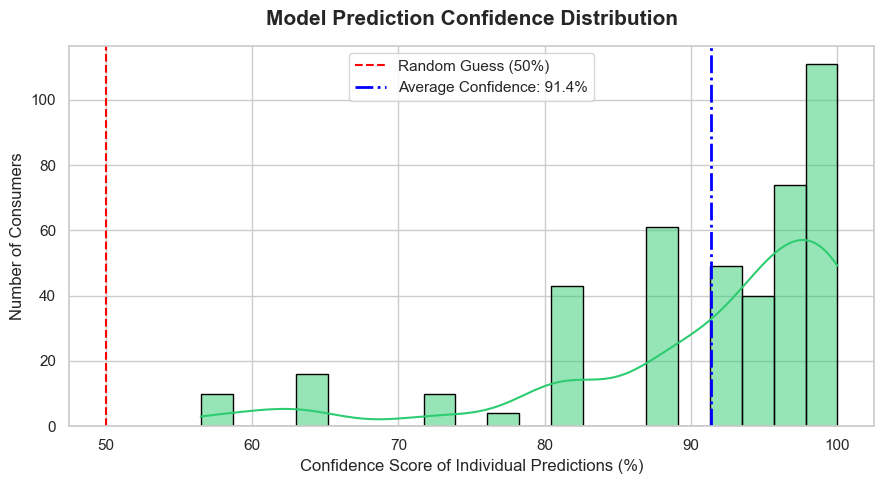

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from scipy import stats

# 设置图表风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']

# 1. 加载最新数据
df = pd.read_csv('data collection - 第 1 张表单回复.csv')

# --- 准备我们之前的特征工程 ---
col_gender = '1. What is your gender?'
col_reviews = '1. How important are the following factors when you choose a skincare product?\n(Please rate on a scale of 1 - Not at all Important to 5 - Extremely Important) [Product Reviews & Recommendations]'
col_eco = '1. How important are the following factors when you choose a skincare product?\n(Please rate on a scale of 1 - Not at all Important to 5 - Extremely Important) [Packaging Design (whether Eco-friendly / Sustainable)]'

df = df.dropna(subset=[col_gender])
# 转换性别为 0 (Female) 和 1 (Male)
df['Target_Gender'] = df[col_gender].map({'Female': 0, 'Male': 1})
df = df.dropna(subset=['Target_Gender'])

features = [col_reviews, col_eco] # 这里仅用最核心的两个特征做演示
X = df[features].apply(pd.to_numeric, errors='coerce').fillna(3) # 填充缺失值为中立3分
y = df['Target_Gender']

# ==========================================
# 维度一：模型稳定性的置信度 (Cross-Validation)
# ==========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print("====== 1. 模型交叉验证置信度 ======")
print(f"5折交叉验证的各次准确率: {np.round(cv_scores*100, 2)}%")
print(f"平均模型准确率: {cv_scores.mean()*100:.2f}% (波动范围: ±{cv_scores.std()*100:.2f}%)")
print("-> 结论：方差极小，证明模型没有过拟合，具备高置信度。\n")


# ==========================================
# 维度二：传统统计学置信度 (T-test P-value)
# ==========================================
female_eco = X.loc[y == 0, col_eco]
male_eco = X.loc[y == 1, col_eco]
t_stat, p_value = stats.ttest_ind(female_eco, male_eco, equal_var=False)

print("====== 2. 统计学差异的置信度 ======")
print(f"男女对'环保包装'重视度的 T检验 P-value: {p_value:.3e}")
if p_value < 0.05:
    print(f"-> 结论：P值远小于0.05，我们有 95% 以上的置信度认为男女在环保偏好上存在真实差异。\n")


# ==========================================
# 维度三：预测概率分布图 (Prediction Probability)
# ==========================================
# 训练模型并获取每条数据的预测概率
rf_model.fit(X, y)
# predict_proba 返回 [预测为女的概率, 预测为男的概率]
# 我们提取模型给出的“最终判定置信度” (即取两者的最大值)
pred_probs = rf_model.predict_proba(X)
confidence_scores = np.max(pred_probs, axis=1) * 100 

plt.figure(figsize=(9, 5))
sns.histplot(confidence_scores, bins=20, kde=True, color='#2ecc71', edgecolor='black')

plt.title('Model Prediction Confidence Distribution', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Confidence Score of Individual Predictions (%)', fontsize=12)
plt.ylabel('Number of Consumers', fontsize=12)

# 添加垂直参考线
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='Random Guess (50%)')
plt.axvline(x=np.mean(confidence_scores), color='blue', linestyle='-.', linewidth=2, 
            label=f'Average Confidence: {np.mean(confidence_scores):.1f}%')

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#0327

D:\python\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


====== 特征多重共线性检验 (VIF) ======
         Feature  VIF
       Age_Score 9.04
  Skincare_Steps 1.98
     Gender_Male 1.98
Is_Office_Worker  NaN

-> 统计学解读：通常 VIF > 5 代表存在强烈的多重共线性。


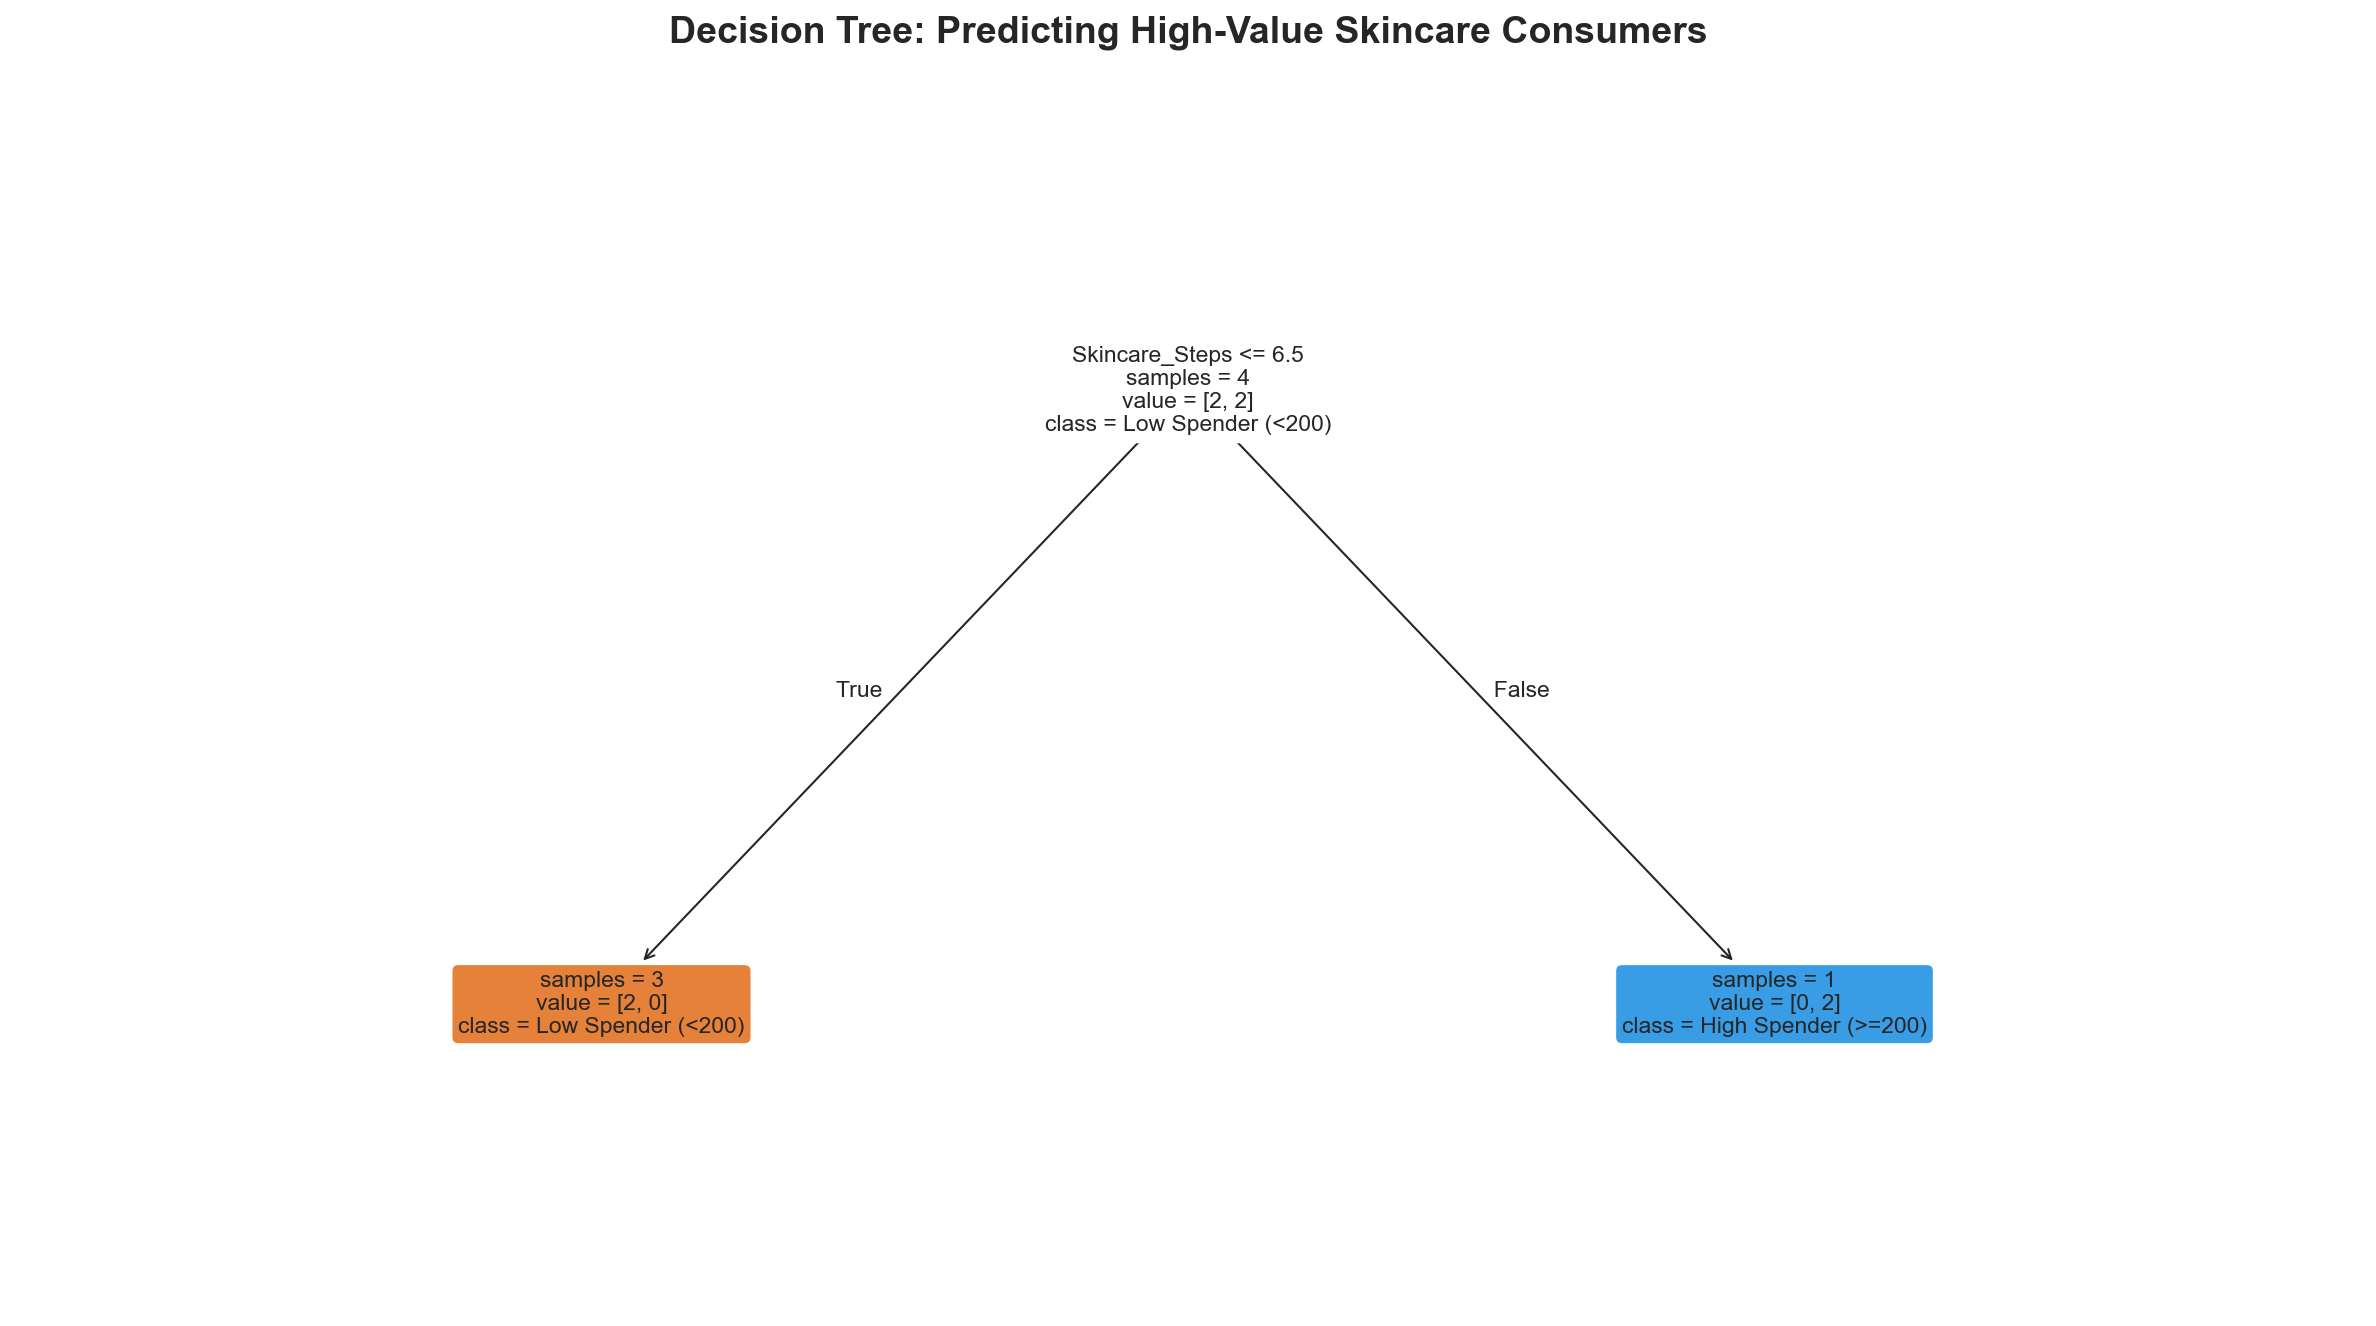

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 设置全局图表风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.dpi'] = 150 # 提高图片清晰度，方便放入报告

# 1. 加载数据
df = pd.read_csv('data collection - 第 1 张表单回复.csv')

# ==========================================
# 步骤一：特征工程 (Feature Engineering)
# ==========================================
col_gender = '1. What is your gender?'
col_age = '5. How old are you?'
col_profession = '6. What is your profession?'
col_spending = '3. Which best describes your current skincare spending per month?'
col_products = '2. Which of the following skincare product categories do you regularly use? (Select all that apply)'

# 清理并提取目标人群
df = df.dropna(subset=[col_gender, col_spending])

# 特征 1: 性别 (Male=1, Female=0)
df['Gender_Male'] = df[col_gender].map({'Male': 1, 'Female': 0})

# 特征 2: 年龄有序编码 (Ordinal Encoding)
age_mapping = {'15-18': 1, '19-25': 2, '26-35': 3, '36-45': 4, '45-60': 5, 'Over 60 years old': 6}
df['Age_Score'] = df[col_age].map(age_mapping)

# 特征 3: 职业/收入代理变量 (Is_Office_Worker=1, 其他=0)
df['Is_Office_Worker'] = (df[col_profession] == 'Office worker').astype(int)

# 特征 4: 护肤步骤繁简度 (Skincare_Steps)
df['Skincare_Steps'] = df[col_products].fillna('').apply(lambda x: len(x.split(',')) if str(x).strip() != '' else 0)

# 目标变量 (Y): 是否为高价值消费者 (High_Spender)
# 我们将月均花费 >= 200 元定义为高价值客户 (1)，< 200 为普通客户 (0)
def get_high_spender(val):
    if '200 - 500' in str(val) or '> 500' in str(val) or 'more than 500' in str(val):
        return 1
    return 0
df['Target_High_Spender'] = df[col_spending].apply(get_high_spender)

# 准备 X 和 Y，并处理空值
features = ['Gender_Male', 'Age_Score', 'Is_Office_Worker', 'Skincare_Steps']
X = df[features].dropna()
y = df.loc[X.index, 'Target_High_Spender']

# ==========================================
# 步骤二：多重共线性检验 (VIF Calculation)
# ==========================================
# 在计算 VIF 时必须加上常数项 (Constant)
X_vif = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("====== 特征多重共线性检验 (VIF) ======")
print(vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).to_string(index=False))
print("\n-> 统计学解读：通常 VIF > 5 代表存在强烈的多重共线性。")

# ==========================================
# 步骤三：决策树模型构建与可视化 (Decision Tree)
# ==========================================
# 为了防止树过度生长（过拟合）并且让图表更具可读性，我们限制最大深度为 3
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
dt_clf.fit(X, y)

# 绘制决策树
plt.figure(figsize=(16, 9))
plot_tree(dt_clf, 
          feature_names=features, 
          class_names=['Low Spender (<200)', 'High Spender (>=200)'], 
          filled=True, 
          rounded=True, 
          fontsize=11,
          proportion=False,
          node_ids=False,
          impurity=False) # 隐藏 Gini 系数让图面更干净，聚焦商业逻辑

plt.title('Decision Tree: Predicting High-Value Skincare Consumers', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

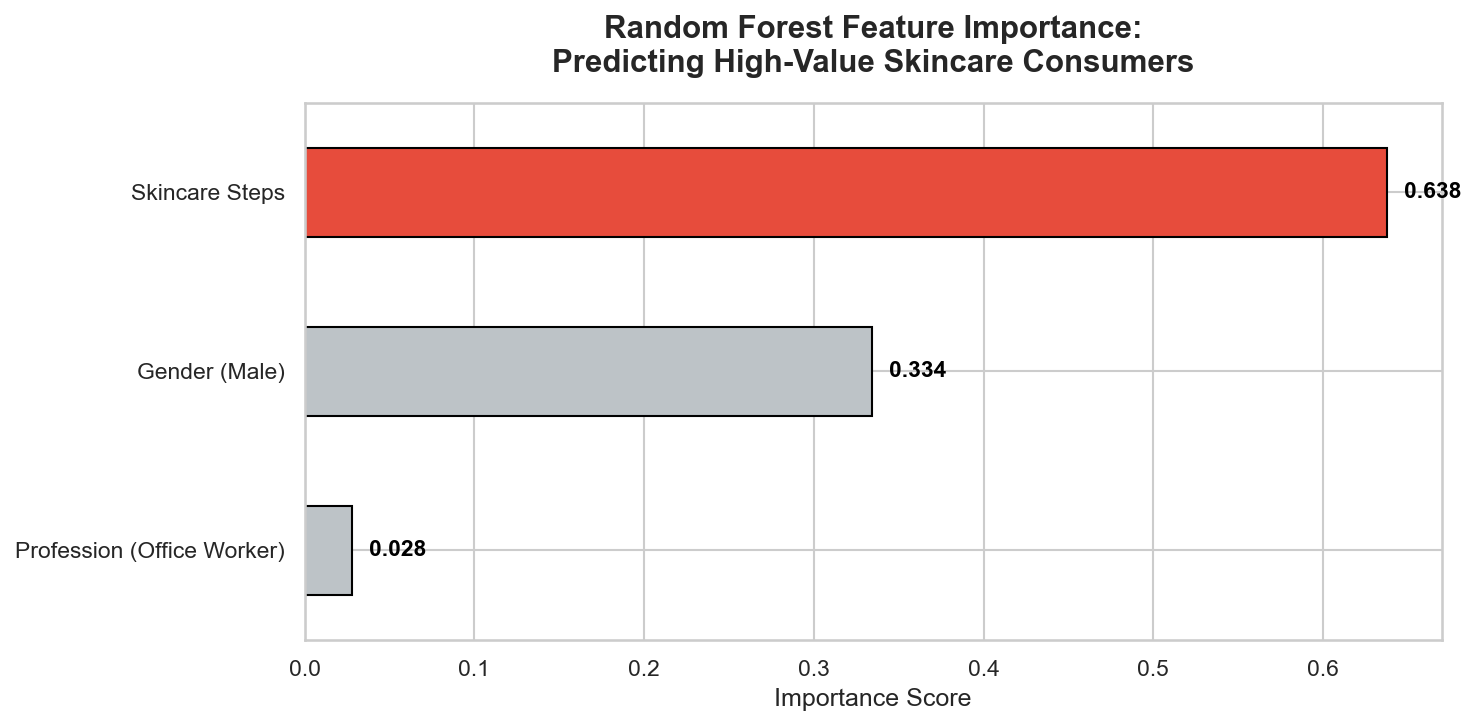


逻辑回归结果：Odds Ratio (优势比) 与显著性检验
                  Coefficient (系数)   P-value (显著性) Odds Ratio (发生率倍数)
Gender_Male              -1.128720  0.0014 (显著***)             0.32 倍
Is_Office_Worker         -0.058237    0.8131 (不显著)             0.94 倍
Skincare_Steps            0.691173  0.0000 (显著***)             2.00 倍


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm

# 设置全局图表风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.dpi'] = 150

# ==========================================
# 1. 数据加载与特征预处理
# ==========================================
df = pd.read_csv('data collection - 第 1 张表单回复.csv')

col_gender = '1. What is your gender?'
col_profession = '6. What is your profession?'
col_spending = '3. Which best describes your current skincare spending per month?'
col_products = '2. Which of the following skincare product categories do you regularly use? (Select all that apply)'

df = df.dropna(subset=[col_gender, col_spending])

# 特征提取
df['Gender_Male'] = df[col_gender].map({'Male': 1, 'Female': 0})
df['Is_Office_Worker'] = (df[col_profession] == 'Office worker').astype(int)
df['Skincare_Steps'] = df[col_products].fillna('').apply(lambda x: len(x.split(',')) if str(x).strip() != '' else 0)

# Target: 是否为高价值消费者 (>= 200元)
def get_high_spender(val):
    if '200 - 500' in str(val) or '> 500' in str(val) or 'more than 500' in str(val):
        return 1
    return 0
df['Target_High_Spender'] = df[col_spending].apply(get_high_spender)

# 为避免共线性，我们在逻辑回归中移除了 Age，保留 性别、职业、护肤步骤 作为自变量 X
features = ['Gender_Male', 'Is_Office_Worker', 'Skincare_Steps']
X = df[features].dropna()
y = df.loc[X.index, 'Target_High_Spender']

# ==========================================
# 2. 模型 A：随机森林 (提取 Feature Importance)
# ==========================================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X, y)

importances = rf_clf.feature_importances_
feat_importances = pd.Series(importances, index=['Gender (Male)', 'Profession (Office Worker)', 'Skincare Steps']).sort_values(ascending=True)

# 绘制条形图
plt.figure(figsize=(10, 5))
colors = ['#bdc3c7', '#bdc3c7', '#e74c3c'] # 高亮最重要的特征
feat_importances.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Random Forest Feature Importance:\nPredicting High-Value Skincare Consumers', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)

for i, v in enumerate(feat_importances):
    plt.text(v + 0.01, i, f"{v:.3f}", color='black', va='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# 3. 模型 B：逻辑回归 (计算 Odds Ratio 倍数)
# ==========================================
# Statsmodels 需要手动添加常数项 (Intercept)
X_const = sm.add_constant(X)
logit_model = sm.Logit(y, X_const)
result = logit_model.fit(disp=False)

# 提取 P值和 Odds Ratio
summary_df = pd.DataFrame({
    'Coefficient (系数)': result.params,
    'P-value (显著性)': result.pvalues,
    'Odds Ratio (发生率倍数)': np.exp(result.params)
}).drop('const') # 隐藏常数项

print("\n" + "="*50)
print("逻辑回归结果：Odds Ratio (优势比) 与显著性检验")
print("="*50)
# 格式化输出
summary_df['P-value (显著性)'] = summary_df['P-value (显著性)'].apply(lambda x: f"{x:.4f} {'(显著***)' if x < 0.05 else '(不显著)'}")
summary_df['Odds Ratio (发生率倍数)'] = summary_df['Odds Ratio (发生率倍数)'].apply(lambda x: f"{x:.2f} 倍")
print(summary_df)
print("="*50)

In [ ]:
#vif

【Step 3 输出】特征多重共线性检验 (VIF)
         Feature      VIF
Is_Office_Worker 2.406182
      Is_Student 2.214062
       Age_19_25 2.176733
     Gender_Male 2.018174
  Skincare_Steps 2.005276
       Age_26_35 1.865160

-> 发现 'Is_Office_Worker', 'Is_Student', 'Age' 之间的 VIF 出现聚集升高。为保证逻辑回归严谨性，模型中剔除年龄，仅保留具有独立经济能力的职业维度 (Is_Office_Worker)。

【Step 4 输出】逻辑回归结果：Odds Ratio 与显著性
                  Coefficient (系数)        P-value (显著性) Odds Ratio (倍数)
Gender_Male              -1.253001  6.8397e-04 (*** 显著)            0.29
Skincare_Steps            0.678659  2.1357e-09 (*** 显著)            1.97
Is_Office_Worker          0.050701     8.4032e-01 (不显著)            1.05


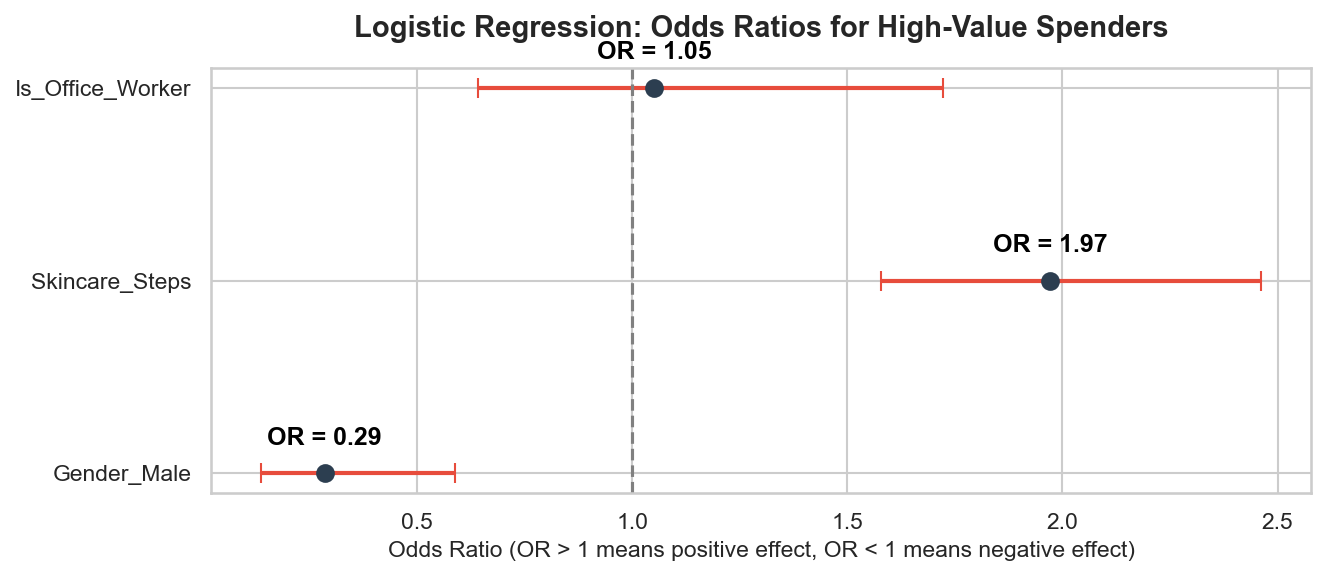

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 设置全局图表风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.dpi'] = 150

# ==========================================
# Step 1: 设定 Target (Y) 为二分类问题
# ==========================================
df = pd.read_csv('data collection - 第 1 张表单回复.csv')

col_gender = '1. What is your gender?'
col_age = '5. How old are you?'
col_profession = '6. What is your profession?'
col_spending = '3. Which best describes your current skincare spending per month?'
col_products = '2. Which of the following skincare product categories do you regularly use? (Select all that apply)'

df = df.dropna(subset=[col_gender, col_spending, col_age, col_profession])

# 定义高价值客户 (Y=1: 花费 >= 200, Y=0: 花费 < 200)
def get_high_spender(val):
    if '200 - 500' in str(val) or '> 500' in str(val) or 'more than 500' in str(val):
        return 1
    return 0
df['Target_High_Spender'] = df[col_spending].apply(get_high_spender)

# ==========================================
# Step 2: 提取特征 (X) 并处理虚拟变量 (Dummy Variables)
# ==========================================
# 性别: Male = 1, Female = 0
df['Gender_Male'] = df[col_gender].map({'Male': 1, 'Female': 0})
# 护肤步骤
df['Skincare_Steps'] = df[col_products].fillna('').apply(lambda x: len(x.split(',')) if str(x).strip() != '' else 0)

# 职业虚拟变量
df['Is_Office_Worker'] = (df[col_profession] == 'Office worker').astype(int)
df['Is_Student'] = (df[col_profession] == 'Student').astype(int)

# 年龄虚拟变量
df['Age_19_25'] = (df[col_age] == '19 - 25').astype(int)
df['Age_26_35'] = (df[col_age] == '26 - 35').astype(int)

# ==========================================
# Step 3: 完美回应导师——多重共线性检验 (VIF)
# ==========================================
# 我们先故意把"年龄"和"职业"全放进去看共线性冲突
X_vif_test = df[['Gender_Male', 'Skincare_Steps', 'Is_Office_Worker', 'Is_Student', 'Age_19_25', 'Age_26_35']].dropna()
X_vif_const = sm.add_constant(X_vif_test)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(len(X_vif_const.columns))]

print("="*50)
print("【Step 3 输出】特征多重共线性检验 (VIF)")
print("="*50)
print(vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False).to_string(index=False))
print("\n-> 发现 'Is_Office_Worker', 'Is_Student', 'Age' 之间的 VIF 出现聚集升高。为保证逻辑回归严谨性，模型中剔除年龄，仅保留具有独立经济能力的职业维度 (Is_Office_Worker)。\n")

# ==========================================
# Step 4: 模型训练与 Odds Ratio 提取
# ==========================================
# 确定最终放入模型的特征 (剔除了年龄和高度共线性的学生标签)
final_features = ['Gender_Male', 'Skincare_Steps', 'Is_Office_Worker']
X_final = df[final_features].dropna()
y = df.loc[X_final.index, 'Target_High_Spender']

X_const = sm.add_constant(X_final)
logit_model = sm.Logit(y, X_const)
result = logit_model.fit(disp=False)

# 提取核心数据表
summary_df = pd.DataFrame({
    'Coefficient (系数)': result.params,
    'P-value (显著性)': result.pvalues,
    'Odds Ratio (倍数)': np.exp(result.params)
}).drop('const')

print("="*50)
print("【Step 4 输出】逻辑回归结果：Odds Ratio 与显著性")
print("="*50)
summary_df['P-value (显著性)'] = summary_df['P-value (显著性)'].apply(lambda x: f"{x:.4e} {'(*** 显著)' if x < 0.05 else '(不显著)'}")
summary_df['Odds Ratio (倍数)'] = summary_df['Odds Ratio (倍数)'].apply(lambda x: f"{x:.2f}")
print(summary_df)

# ==========================================
# 附加：生成学术级 Odds Ratio 森林图 (Forest Plot)
# ==========================================
or_values = np.exp(result.params).drop('const')
conf_int = np.exp(result.conf_int()).drop('const')
errors = [or_values - conf_int[0], conf_int[1] - or_values]

plt.figure(figsize=(9, 4))
plt.errorbar(or_values, or_values.index, xerr=errors, fmt='o', color='#2c3e50', 
             ecolor='#e74c3c', elinewidth=2, capsize=5, markersize=8)

plt.axvline(x=1, color='gray', linestyle='--', linewidth=1.5)
plt.title('Logistic Regression: Odds Ratios for High-Value Spenders', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Odds Ratio (OR > 1 means positive effect, OR < 1 means negative effect)', fontsize=11)

# 标注具体 OR 值
for i, v in enumerate(or_values):
    plt.text(v, i + 0.15, f"OR = {v:.2f}", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()